# TCGA CNA Processing (Xena)

This notebook:
- Loads CNA data
- Cleans gene identifiers (ENSG → HGNC)
- Aggregates to cancer-level
- Filters protein-coding genes
- Exports clean matrix


In [1]:

import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
import gzip, re, os
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

SAVE_DIR = "data/tcga"
os.makedirs(SAVE_DIR, exist_ok=True)

CNA_FILE  = "../../ACGNN_data/data/TCGA.PANCAN.sampleMap_Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes.gz"
PHENO_FILE = "../../ACGNN_data/data/TCGA_phenotype_denseDataOnlyDownload.tsv.gz"
GTF_PATH = "../../ACGNN_data/data/gencode.v38.annotation.gtf.gz"

COLORS = {
    0: '#0077B6',   1: '#0000FF',   2: '#00B4D8',   3: '#48EAC4',
    4: '#F1C0E8',   5: '#B9FBC0',   6: '#32CD32',   7: '#BEE1E6',
    8: '#8A2BE2',   9: '#E377C2',  10: '#8EECF5',  11: '#A3C4F3',
    12: '#FFB347', 13: '#FFD700',  14: '#FF69B4',  15: '#CD5C5C',
    16: '#7FFFD4', 17: '#FF7F50',  18: '#C71585',  19: '#20B2AA',
    20: '#6A5ACD', 21: '#40E0D0',  22: '#FF8C00',  23: '#DC143C',
    24: '#9ACD32',
    25: '#1F77B4', 26: '#FF1493', 27: '#2E8B57', 28: '#D2691E',
    29: '#9932CC', 30: '#00CED1', 31: '#FF4500', 32: '#708090'
}


disease_to_tcga = {
    "adrenocortical carcinoma": "ACC",
    "bladder urothelial carcinoma": "BLCA",
    "breast invasive carcinoma": "BRCA",
    "cervical squamous cell carcinoma and endocervical adenocarcinoma": "CESC",
    "cholangiocarcinoma": "CHOL",
    "colon adenocarcinoma": "COAD",
    "rectum adenocarcinoma": "READ",
    "diffuse large B-cell lymphoma": "DLBC",
    "esophageal carcinoma": "ESCA",
    "glioblastoma multiforme": "GBM",
    "head and neck squamous cell carcinoma": "HNSC",
    "kidney chromophobe": "KICH",
    "kidney renal clear cell carcinoma": "KIRC",
    "kidney renal papillary cell carcinoma": "KIRP",
    "acute myeloid leukemia": "LAML",
    "brain lower grade glioma": "LGG",
    "liver hepatocellular carcinoma": "LIHC",
    "lung adenocarcinoma": "LUAD",
    "lung squamous cell carcinoma": "LUSC",
    "mesothelioma": "MESO",
    "ovarian serous cystadenocarcinoma": "OV",
    "pancreatic adenocarcinoma": "PAAD",
    "pheochromocytoma and paraganglioma": "PCPG",
    "prostate adenocarcinoma": "PRAD",
    "sarcoma": "SARC",
    "skin cutaneous melanoma": "SKCM",
    "stomach adenocarcinoma": "STAD",
    "testicular germ cell tumors": "TGCT",
    "thyroid carcinoma": "THCA",
    "thymoma": "THYM",
    "uterine corpus endometrial carcinoma": "UCEC",
    "uterine carcinosarcoma": "UCS",
    "uveal melanoma": "UVM"
}

len(set(disease_to_tcga.values()))


33

## Load CNA

In [ ]:

cna = pd.read_csv(CNA_FILE, sep="\t", compression="gzip")
cna.rename(columns={cna.columns[0]: "gene"}, inplace=True)
print(cna.shape)


## Clean Gene IDs

In [ ]:

def split_gene_ids(g):
    if "|" in str(g):
        parts = g.split("|")
        return parts[0], parts[1]
    return g, None

gene_info = cna["gene"].apply(split_gene_ids)
gene_df = pd.DataFrame(gene_info.tolist(), columns=["symbol_raw", "ensembl"])


## Parse GTF

In [ ]:

def parse_gtf(gtf_path):
    mapping = {}
    gene_type = {}

    with gzip.open(gtf_path, "rt") as f:
        for line in f:
            if line.startswith("#"):
                continue
            fields = line.split("\t")
            if fields[2] != "gene":
                continue

            attr = fields[8]

            ensg = re.search('gene_id "([^"]+)"', attr)
            symbol = re.search('gene_name "([^"]+)"', attr)
            gtype = re.search('gene_type "([^"]+)"', attr)

            if ensg and symbol:
                mapping[ensg.group(1)] = symbol.group(1)
                gene_type[symbol.group(1)] = gtype.group(1) if gtype else "unknown"

    return mapping, gene_type

ensembl_map, gene_type = parse_gtf(GTF_PATH)


## Map to HGNC

In [ ]:

def clean_gene(row):
    raw = row["symbol_raw"]
    ensg = row["ensembl"]
    if ensg and ensg in ensembl_map:
        return ensembl_map[ensg]
    return raw

gene_df["gene_clean"] = gene_df.apply(clean_gene, axis=1)
cna["gene"] = gene_df["gene_clean"]


## Filter protein-coding

In [ ]:

protein_genes = {g for g, t in gene_type.items() if t == "protein_coding"}
cna = cna[cna["gene"].isin(protein_genes)]


## Load phenotype

In [ ]:

pheno = pd.read_csv(PHENO_FILE, sep="\t", compression="gzip")
pheno["Sample"] = pheno["sample"]
pheno["_primary_disease"] = pheno["_primary_disease"].str.lower().str.strip()

# disease_to_tcga = {
#     "breast invasive carcinoma": "BRCA",
#     "lung adenocarcinoma": "LUAD",
#     "lung squamous cell carcinoma": "LUSC"
# }

pheno["Cancer"] = pheno["_primary_disease"].map(disease_to_tcga)
pheno = pheno.dropna(subset=["Cancer"])


## Aggregate to cancer

In [ ]:

def aggregate(df, pheno_df):
    common = list(set(df.columns) & set(pheno_df["Sample"]))
    df = df[["gene"] + common]
    pheno_df = pheno_df[pheno_df["Sample"].isin(common)]

    cancer_dict = {}

    for s in common:
        c = pheno_df.loc[pheno_df["Sample"] == s, "Cancer"].values
        if len(c) == 0:
            continue
        c = c[0]
        cancer_dict.setdefault(c, []).append(df[s].values)

    cancers = sorted(cancer_dict.keys())

    mat = np.array([np.mean(cancer_dict[c], axis=0) for c in cancers]).T

    out = pd.DataFrame(mat, columns=cancers)
    out.insert(0, "gene", df["gene"].values)
    return out

cna_df = aggregate(cna, pheno)
cna_df = cna_df.groupby("gene", as_index=False).mean()
print(cna_df.shape)


(17606, 25)


## Save

In [ ]:

out = os.path.join(SAVE_DIR, "cna_features.csv")
cna_df.to_csv(out, index=False)
print("Saved:", out)


Saved: data/tcga/cna_features.csv


## CNA Value Distribution

We visualize the distribution of CNA values across all genes and samples.

This helps verify:
- Expected discrete levels (-2 to 2)  
- Data integrity  
- Presence of extreme alterations  

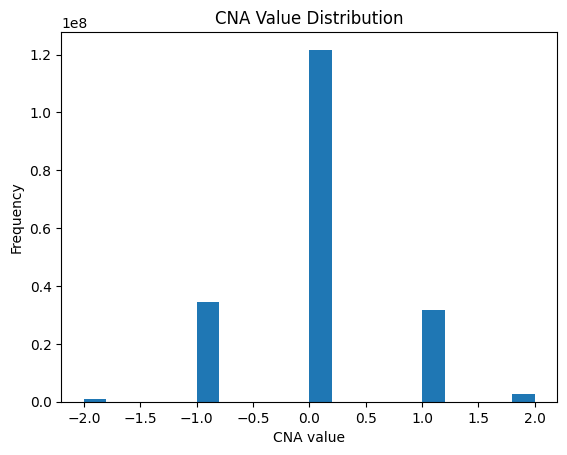

In [ ]:
# %%
cna_vals = cna.iloc[:, 1:].values.flatten()

cna_vals = cna_vals[~np.isnan(cna_vals)]

plt.figure()
plt.hist(cna_vals, bins=20)

plt.title("CNA Value Distribution")
plt.xlabel("CNA value")
plt.ylabel("Frequency")

plt.show()

## Gene-Level CNA Burden

We compute the average absolute CNA signal per gene:

$$
\text{Burden}_g = \frac{1}{N} \sum |x_{g,s}|
$$

This identifies genes with frequent amplifications or deletions.

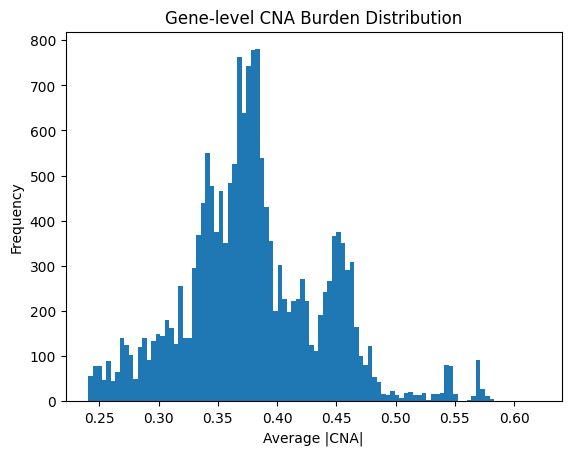

In [ ]:
# %%
gene_burden = np.abs(cna.iloc[:, 1:]).mean(axis=1)

plt.figure()
plt.hist(gene_burden, bins=100)

plt.title("Gene-level CNA Burden Distribution")
plt.xlabel("Average |CNA|")
plt.ylabel("Frequency")

plt.show()

## Top Altered Genes

Visualize genes with the highest CNA burden across samples.

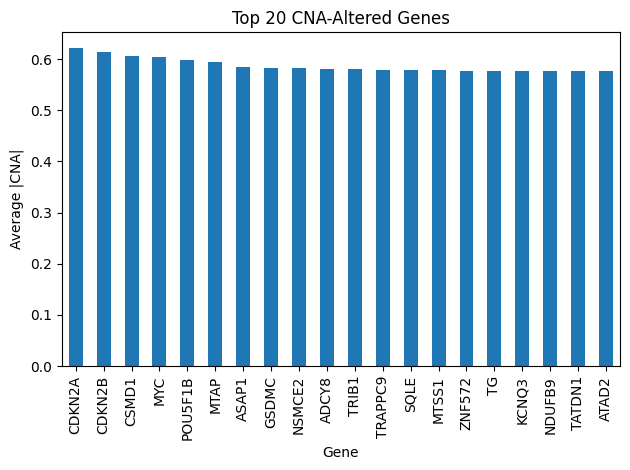

In [ ]:
# Attach gene names to burden
gene_burden = pd.Series(
    np.abs(cna.iloc[:, 1:]).mean(axis=1).values,
    index=cna["gene"]
)

# Get top genes
top_genes = gene_burden.sort_values(ascending=False).head(20)

# Plot
plt.figure()
top_genes.plot(kind="bar")

plt.title("Top 20 CNA-Altered Genes")
plt.xlabel("Gene")
plt.ylabel("Average |CNA|")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## PCA of CNA Features

We apply PCA to visualize global variation across cancer types.

$$
Z = X W
$$

where $W$ contains principal components.

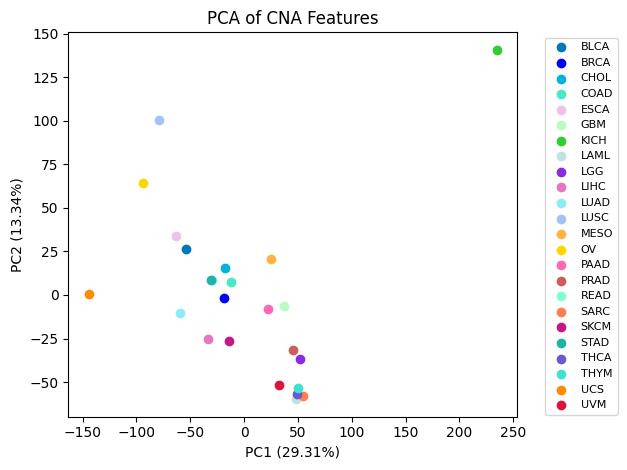

In [ ]:
# %%
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = cna_df.set_index("gene").T

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
emb = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_

plt.figure()

for i, cancer in enumerate(X.index):
    plt.scatter(
        emb[i, 0],
        emb[i, 1],
        color=COLORS.get(i, "#333333"),
        label=cancer
    )

plt.xlabel(f"PC1 ({var_exp[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.2f}%)")
plt.title("PCA of CNA Features")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## CNA Heatmap (Top Variable Genes)

We visualize highly variable genes across cancer types to identify patterns of genomic alteration.

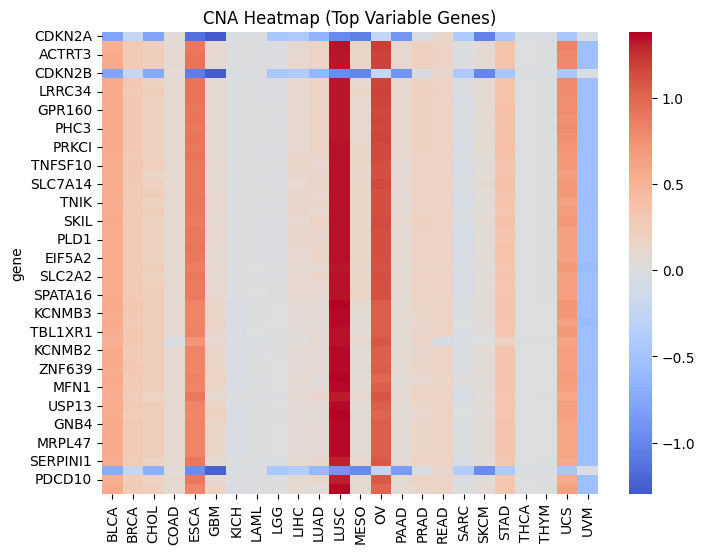

In [ ]:
# %%
import seaborn as sns

# select top variable genes
var_genes = cna_df.set_index("gene").var(axis=1).sort_values(ascending=False).head(50).index

heatmap_data = cna_df.set_index("gene").loc[var_genes]

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0)

plt.title("CNA Heatmap (Top Variable Genes)")
# plt.xlabel("Cancer Type")
# plt.ylabel("Gene")

plt.show()